In [2]:
import tensorflow as tf
import numpy as np
import random
import os
import pandas as pd
# Set all random seeds and deterministic operations
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

ImportError: Traceback (most recent call last):
  File "c:\Users\User\Desktop\ML_Project\mlenv\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 73, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: A dynamic link library (DLL) initialization routine failed.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.

In [ ]:
df = pd.read_csv(r"C:\Users\User\Desktop\ML_Project\Data\processed\maharashtra_model_ready.csv")
print(df.head())

   Unnamed: 0    district  year  month  rainfall_mm  SoilMoi_0_10  \
0           0  Ahmednagar  2015      6   127.566858      0.297236   
1           1  Ahmednagar  2015      7    52.172304      0.234076   
2           2  Ahmednagar  2015      8    65.907127      0.283227   
3           3  Ahmednagar  2015      9   211.699473      0.343166   
4           4  Ahmednagar  2015     10    72.067995      0.289113   

   SoilMoi_10_40  SoilMoi_40_100  SoilMoi_100_200  et_mean_mm  ...  \
0       0.297696        0.257036         0.349434    6.980997  ...   
1       0.321313        0.282012         0.352772   10.912704  ...   
2       0.327283        0.296945         0.355740   15.930731  ...   
3       0.356753        0.334319         0.365064   15.043684  ...   
4       0.352400        0.357233         0.376176    9.686445  ...   

   soil_0_10_lag3    et_lag3  rainfall_roll3  rainfall_roll6  \
0        0.157638   3.045763       51.386090       27.008090   
1        0.173251   1.919723       6

In [ ]:
df = df.drop(df.filter(like="Unnamed:").columns, axis=1)

In [ ]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['district_encoded'] = le.fit_transform(df['district'])

In [ ]:
# Count rows per district
district_counts = df.groupby("district_encoded").size().reset_index(name="num_rows")

# Sort by number of rows
district_counts = district_counts.sort_values(by="num_rows", ascending=False)

print(district_counts)

    district_encoded  num_rows
0                  0       109
1                  1       109
2                  2       109
3                  3       109
4                  4       109
5                  5       109
6                  6       109
7                  7       109
8                  8       109
9                  9       109
10                10       109
11                11       109
12                12       109
13                13       109
14                14       109
15                15       109
16                16       109
17                17       109
18                18       109
19                19       109
20                20       109
21                21       109
22                22       109
23                23       109
24                24       109
25                25       109
26                26       109
27                27       109
28                28       109
29                29       109
30                30       109
31      

In [ ]:
lstm_features = ['rainfall_mm', 'SoilMoi_0_10', 'SoilMoi_10_40', 'et_mean_mm', 'ndvi', 'mean_temp_c', 'month_sin', 'month_cos', 'district_encoded']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[lstm_features])
target_encoder = LabelEncoder()
df['target_encoded'] = target_encoder.fit_transform(df['target_1m_ahead'])


In [ ]:
SEQ_LENGTH = 12  # 1 year of history

X_sequences = []      # Time series data
X_district = []       # District IDs
y_sequences = []      # Targets
sequence_dates = []   # Dates for each prediction

for district_id in sorted(df['district_encoded'].unique()):
    district_data = df[df['district_encoded'] == district_id].copy()

    # Create sequences for this district
    for i in range(SEQ_LENGTH, len(district_data)):
        # Time series features (without district)
        X_sequences.append(district_data[lstm_features].iloc[i-SEQ_LENGTH:i].values)

        # District ID (repeated for each sequence)
        X_district.append(district_id)

        # Target
        y_sequences.append(district_data['target_encoded'].iloc[i])

        # Date for this prediction
        sequence_dates.append(district_data['date'].iloc[i])

# Convert to arrays
X_sequences = np.array(X_sequences)
X_district = np.array(X_district)
y_sequences = np.array(y_sequences)
sequence_dates = np.array(sequence_dates)

In [ ]:
# Split based on date (2015-2021 train, 2022-2024 test)
train_mask = sequence_dates < pd.to_datetime('2022-01-01')
test_mask = sequence_dates >= pd.to_datetime('2022-01-01')

X_train_seq, X_test_seq = X_sequences[train_mask], X_sequences[test_mask]
X_train_district, X_test_district = X_district[train_mask], X_district[test_mask]
y_train, y_test = y_sequences[train_mask], y_sequences[test_mask]

print(f"Training sequences: {X_train_seq.shape}")
print(f"Training districts: {X_train_district.shape}")
print(f"Test sequences: {X_test_seq.shape}")

Training sequences: (2345, 12, 9)
Training districts: (2345,)
Test sequences: (1050, 12, 9)


In [ ]:
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Embedding, Concatenate, Flatten, RepeatVector
from tensorflow.keras.models import Model

# Input dimensions
num_districts = len(df['district_encoded'].unique())
seq_length = SEQ_LENGTH
num_features = len(lstm_features)
num_classes = len(target_encoder.classes_)

# Input for time series data
ts_input = Input(shape=(seq_length, num_features), name='time_series_input')

# Input for district ID
district_input = Input(shape=(1,), name='district_input')

# District embedding (learns representations for each district)
district_embedding = Embedding(
    input_dim=num_districts,
    output_dim=5,  # 5-dimensional embedding for each district
    name='district_embedding'
)(district_input)

# Flatten and repeat the embedding for each time step
district_embedding = Flatten()(district_embedding)
district_embedding = RepeatVector(seq_length)(district_embedding)

# Concatenate time series data with district embedding
combined = Concatenate(axis=-1)([ts_input, district_embedding])

# LSTM layers
lstm1 = LSTM(64, return_sequences=True, name='lstm1')(combined)
dropout1 = Dropout(0.3, name='dropout1')(lstm1)
lstm2 = LSTM(32, name='lstm2')(dropout1)
dropout2 = Dropout(0.3, name='dropout2')(lstm2)

# Output layer
output = Dense(num_classes, activation='softmax', name='output')(dropout2)

# Create model
model = Model(inputs=[ts_input, district_input], outputs=output)

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],

    run_eagerly = False
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ district_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ district_embedding  │ (None, 1, 5)      │        175 │ district_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 5)         │          0 │ district_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_series_input   │ (None, 12, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 12, 5)     │          0 │ flatten_2[0][0]   │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 12, 14)    │          0 │ time_series_inpu… │
│ (Concatenate)       │                   │            │ repeat_vector_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm1 (LSTM)        │ (None, 12, 64)    │     20,224 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 12, 64)    │          0 │ lstm1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm2 (LSTM)        │ (None, 32)        │     12,416 │ dropout1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout2 (Dropout)  │ (None, 32)        │          0 │ lstm2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │         99 │ dropout2[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,914 (128.57 KB)

 Trainable params: 32,914 (128.57 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train with both inputs
history = model.fit(
    [X_train_seq, X_train_district],  # Two inputs: time series + district
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=([X_test_seq, X_test_district], y_test),
    verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
    ]
)

Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.6714 - loss: 0.7579 - val_accuracy: 0.8438 - val_loss: 0.3942 - learning_rate: 0.0010
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8267 - loss: 0.4522 - val_accuracy: 0.8705 - val_loss: 0.3236 - learning_rate: 0.0010
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8517 - loss: 0.3858 - val_accuracy: 0.8819 - val_loss: 0.2968 - learning_rate: 0.0010
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8697 - loss: 0.3588 - val_accuracy: 0.8771 - val_loss: 0.2889 - learning_rate: 0.0010
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8767 - loss: 0.3271 - val_accuracy: 0.8924 - val_loss: 0.2792 - learning_rate: 0.0010
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8764 - loss: 0.3153 - val_accuracy: 0.8848 - val_loss: 0.2870 - learning_rate: 0.0010
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8867 - loss: 0.3066 - val_acc

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
=== OVERALL PREDICTIONS ===
Total test sequences: 1050
Overall Accuracy: 0.890

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Extreme       0.81      0.91      0.86       236
    Moderate       0.53      0.26      0.34        82
  No Drought       0.94      0.95      0.95       732

    accuracy                           0.89      1050
   macro avg       0.76      0.71      0.72      1050
weighted avg       0.88      0.89      0.88      1050



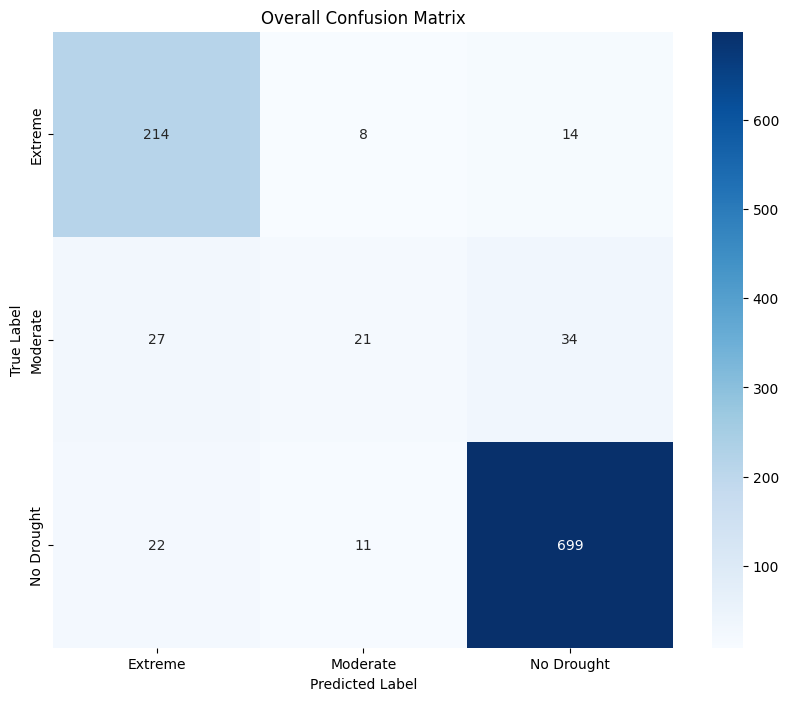

In [ ]:
# Make predictions on the entire test set
y_pred_proba = model.predict([X_test_seq, X_test_district])
y_pred = np.argmax(y_pred_proba, axis=1)
y_pred_labels = target_encoder.inverse_transform(y_pred)
y_true_labels = target_encoder.inverse_transform(y_test)

# Overall performance
from sklearn.metrics import classification_report, confusion_matrix

print("=== OVERALL PREDICTIONS ===")
print(f"Total test sequences: {len(y_test)}")
print(f"Overall Accuracy: {np.mean(y_pred == y_test):.3f}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true_labels, y_pred_labels, target_names=target_encoder.classes_))

# Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_labels, y_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.title('Overall Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# Create a DataFrame for analysis
results_df = pd.DataFrame({
    'district': X_test_district,
    'true_label': y_true_labels,
    'predicted_label': y_pred_labels,
    'correct': (y_pred_labels == y_true_labels)
})

# District-wise accuracy
district_accuracy = results_df.groupby('district')['correct'].mean().reset_index()
district_accuracy.columns = ['district_id', 'accuracy']

print("=== DISTRICT-WISE ACCURACY ===")
print(district_accuracy.sort_values('accuracy', ascending=False))

# Get district names mapping
district_names = df[['district', 'district_encoded']].drop_duplicates().sort_values('district_encoded')
district_accuracy = district_accuracy.merge(district_names, left_on='district_id', right_on='district_encoded')

print("\n=== TOP 5 DISTRICTS ===")
print(district_accuracy[['district', 'accuracy']].sort_values('accuracy', ascending=False).head(5))

print("\n=== BOTTOM 5 DISTRICTS ===")
print(district_accuracy[['district', 'accuracy']].sort_values('accuracy', ascending=True).head(5))

=== DISTRICT-WISE ACCURACY ===
    district_id  accuracy
25           25  1.000000
17           17  0.966667
21           21  0.966667
31           31  0.966667
22           22  0.933333
0             0  0.933333
26           26  0.933333
16           16  0.933333
7             7  0.933333
12           12  0.933333
15           15  0.933333
20           20  0.933333
2             2  0.900000
9             9  0.900000
30           30  0.900000
8             8  0.900000
29           29  0.866667
14           14  0.866667
4             4  0.866667
34           34  0.866667
24           24  0.866667
28           28  0.866667
18           18  0.866667
10           10  0.866667
11           11  0.866667
13           13  0.866667
19           19  0.866667
27           27  0.866667
32           32  0.866667
23           23  0.833333
3             3  0.833333
33           33  0.833333
5             5  0.833333
6             6  0.800000
1             1  0.766667

=== TOP 5 DISTRICTS ===
        

In [ ]:
# Detailed analysis for each district
district_reports = []

for district_id in sorted(results_df['district'].unique()):
    district_data = results_df[results_df['district'] == district_id]
    district_name = district_names[district_names['district_encoded'] == district_id]['district'].values[0]

    accuracy = np.mean(district_data['correct'])
    total_samples = len(district_data)

    # Class-wise performance
    class_report = classification_report(district_data['true_label'],
                                       district_data['predicted_label'],
                                       output_dict=True,
                                       zero_division=0)

    district_reports.append({
        'district_id': district_id,
        'district_name': district_name,
        'accuracy': accuracy,
        'total_samples': total_samples,
        'extreme_recall': class_report['Extreme']['recall'] if 'Extreme' in class_report else 0,
        'moderate_recall': class_report['Moderate']['recall'] if 'Moderate' in class_report else 0,
        'no_drought_recall': class_report['No Drought']['recall'] if 'No Drought' in class_report else 0
    })

# Create comprehensive report
district_report_df = pd.DataFrame(district_reports)
print("=== COMPREHENSIVE DISTRICT REPORT ===")
print(district_report_df.sort_values('accuracy', ascending=False).to_string())

=== COMPREHENSIVE DISTRICT REPORT ===
    district_id    district_name  accuracy  total_samples  extreme_recall  moderate_recall  no_drought_recall
25           25          Raigarh  1.000000             30        1.000000         0.000000           1.000000
17           17  Mumbai Suburban  0.966667             30        1.000000         0.000000           1.000000
21           21           Nashik  0.966667             30        0.916667         0.000000           1.000000
31           31            Thane  0.966667             30        1.000000         0.000000           1.000000
22           22        Osmanabad  0.933333             30        1.000000         0.000000           0.956522
0             0       Ahmednagar  0.933333             30        1.000000         0.500000           0.950000
26           26        Ratnagiri  0.933333             30        1.000000         0.000000           1.000000
16           16      Mumbai City  0.933333             30        0.916667         

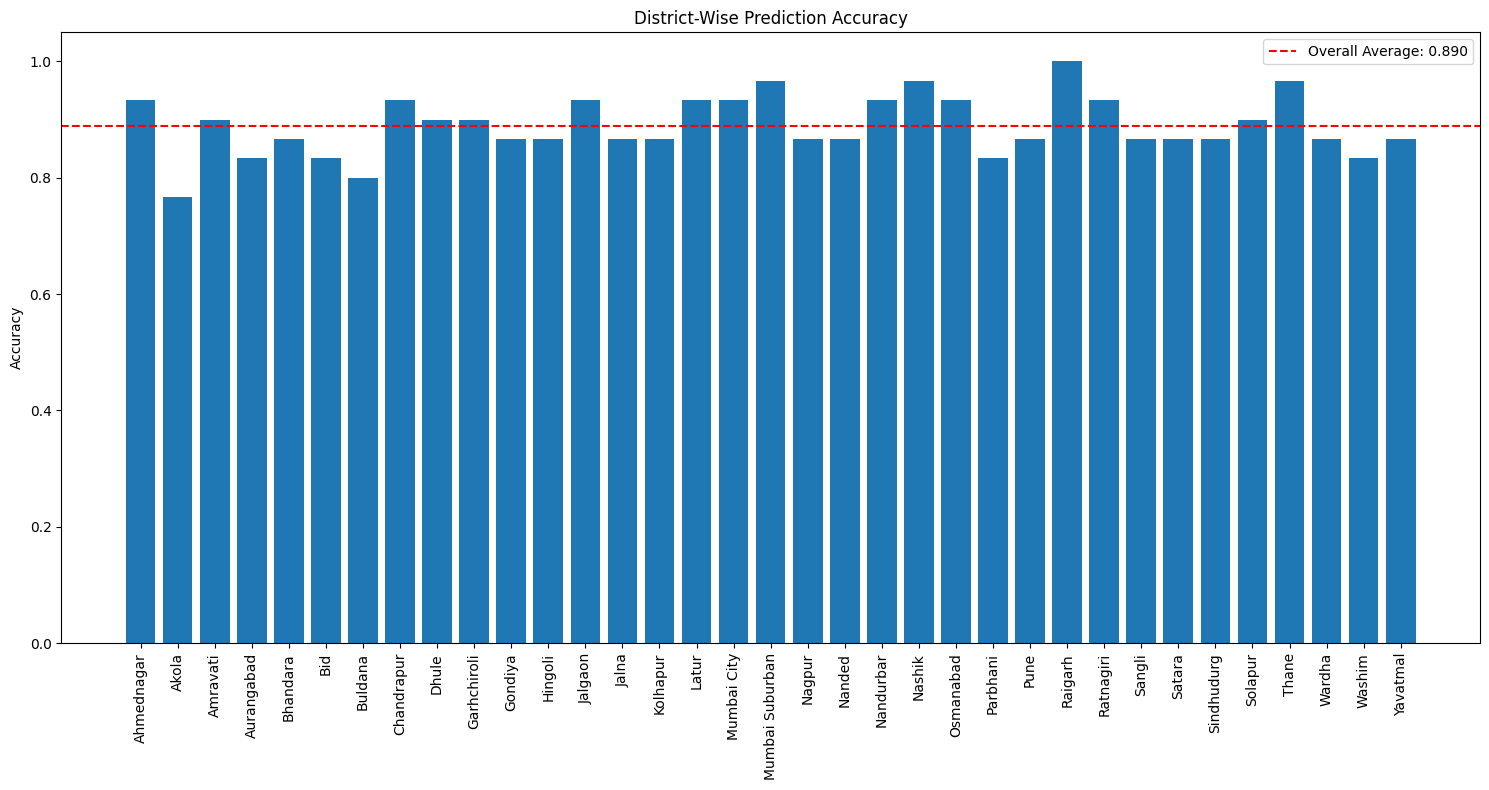

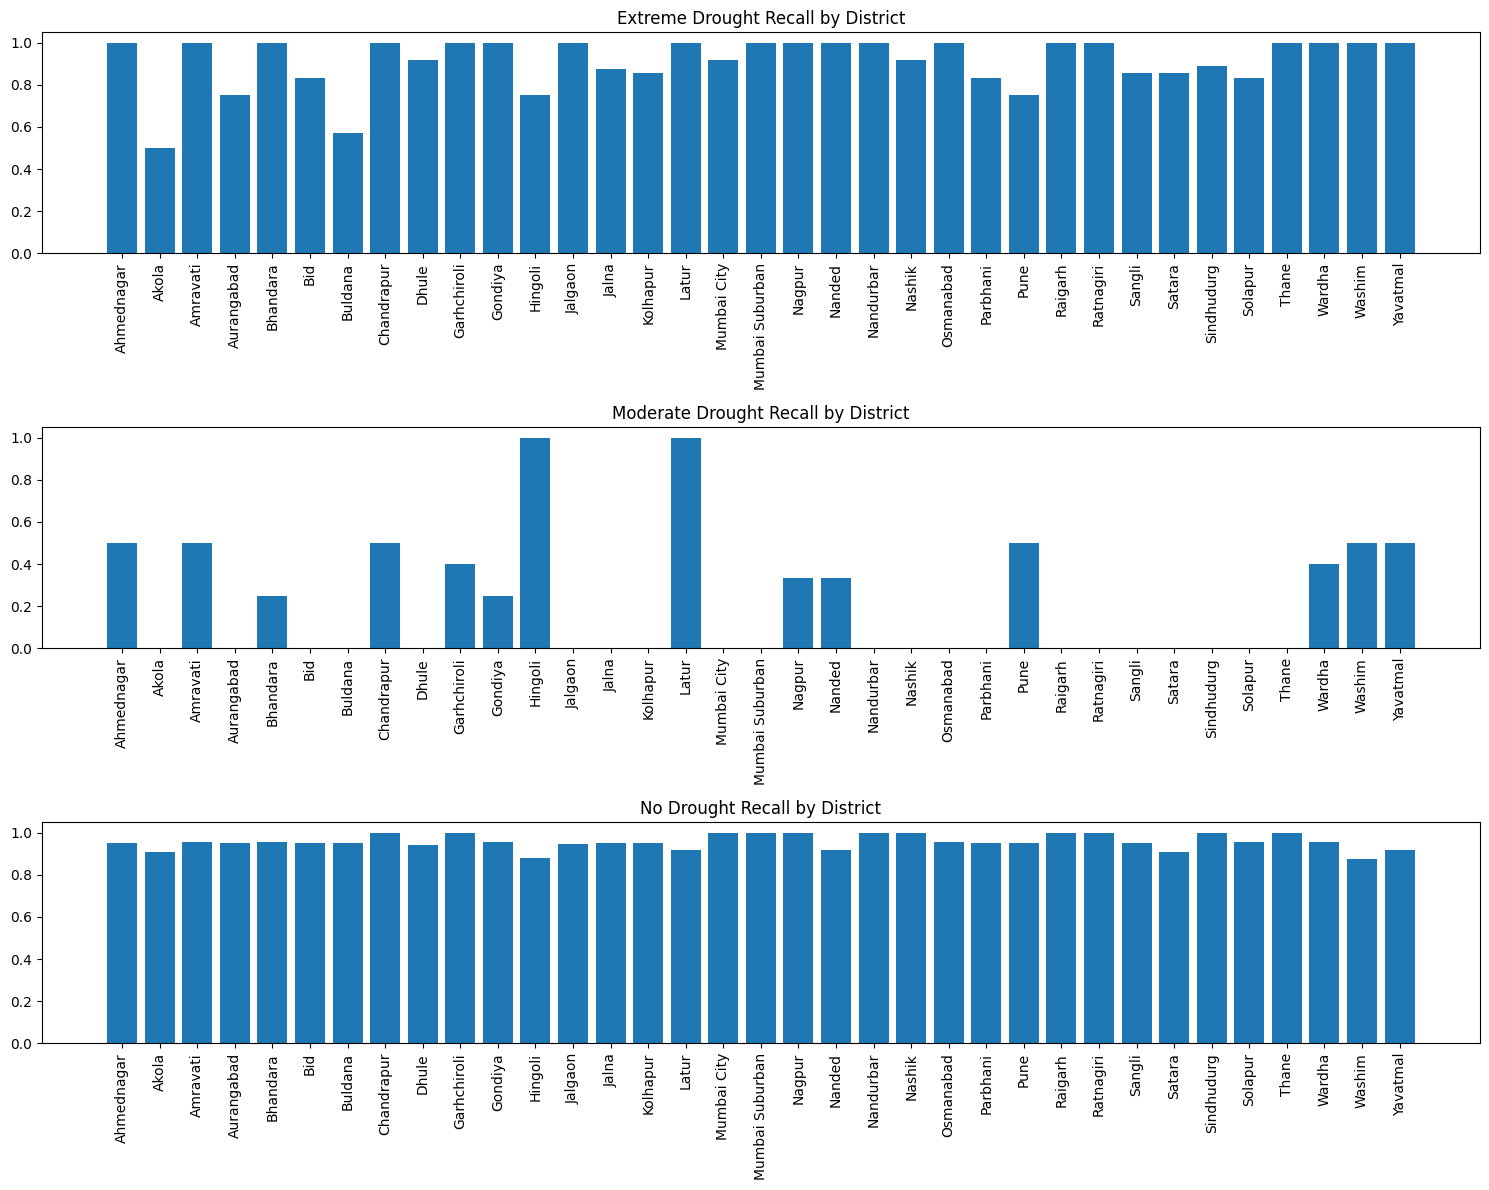

In [ ]:
# Plot district-wise accuracy
plt.figure(figsize=(15, 8))
plt.bar(district_report_df['district_name'], district_report_df['accuracy'])
plt.xticks(rotation=90)
plt.title('District-Wise Prediction Accuracy')
plt.ylabel('Accuracy')
plt.axhline(y=district_report_df['accuracy'].mean(), color='r', linestyle='--', label=f'Overall Average: {district_report_df["accuracy"].mean():.3f}')
plt.legend()
plt.tight_layout()
plt.show()

# Plot recall for each drought class by district
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Extreme drought recall
axes[0].bar(district_report_df['district_name'], district_report_df['extreme_recall'])
axes[0].set_title('Extreme Drought Recall by District')
axes[0].tick_params(axis='x', rotation=90)

# Moderate drought recall
axes[1].bar(district_report_df['district_name'], district_report_df['moderate_recall'])
axes[1].set_title('Moderate Drought Recall by District')
axes[1].tick_params(axis='x', rotation=90)

# No drought recall
axes[2].bar(district_report_df['district_name'], district_report_df['no_drought_recall'])
axes[2].set_title('No Drought Recall by District')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()